In [2]:
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_absolute_error
from nltk.cluster.kmeans import KMeansClusterer
from nltk.cluster.util import euclidean_distance
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo
# fetch dataset
support2 = fetch_ucirepo(id=880)

import umap.umap_ as umap
import matplotlib.pyplot as plt

from models import *
from my_encodings import *

In [ ]:
# --------------------------- Initialize dataset ------------------------------
# data (as pandas dataframes)
features = support2.data.features
targets = support2.data.targets


# join together as 1 df for EDA 
df = features.join(targets)
df = df.drop(columns=['death', 'hospdead', 'adlp', 'adls', 'scoma', 'totmcst', 'totcst', 'sps', 'aps', 'hday', \
                      'adlsc', 'prg2m', 'prg6m', 'charges', 'dzgroup', 'dnr', 'dnrday', 'urine',
                      'surv2m', 'surv6m']) # added surv2m, surv6m to drop; prevent data leakage

# drop rows where target = NaN
print(f'Before dropping NaNs in target: {df.shape[0]}')
df = df.dropna(subset=['sfdm2'])

print(f'After dropping NaNs in target: {df.shape[0]}')

# check remaining columns
print(df.columns)
print(len(df.columns))

Before dropping NaNs in target: 9105
After dropping NaNs in target: 7705
Index(['age', 'sex', 'dzclass', 'num.co', 'edu', 'income', 'avtisst', 'race',
       'diabetes', 'dementia', 'ca', 'meanbp', 'wblc', 'hrt', 'resp', 'temp',
       'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'sfdm2'],
      dtype='str')
25


Pipeline for encoding, scaling, and imputing NaNs

https://www.geeksforgeeks.org/machine-learning/handling-missing-data-with-knn-imputer/

for numerical features
   1) impute
   2) scale


for categorical features
   1) encode to numerical
   2) impute

In [4]:
X = df.drop(columns=['sfdm2'])
y = df[['sfdm2']]

# split into training vs test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# # using LabelEncoder
# le = LabelEncoder()
# y_encoded = le.fit_transform(y_train)
# y_train = pd.DataFrame(y_encoded, columns=['sfdm2'])

# y_test_encoded = le.transform(y_test)
# y_test = pd.DataFrame(y_test_encoded, columns=['sfdm2'])
# print(f"Contains missing values: {y_train.isna().any().any()}")
# print(f"Contains missing values: {y_test.isna().any().any()}")

In [5]:
X_train.shape

(6164, 24)

In [6]:
y_train

,sfdm2
6549,SIP>=30
1659,no(M2 and SIP pres)
7399,<2 mo. follow-up
3668,adl>=4 (>=5 if sur)
2034,<2 mo. follow-up
...,...
6258,adl>=4 (>=5 if sur)
6432,no(M2 and SIP pres)
1155,<2 mo. follow-up
8986,no(M2 and SIP pres)


In [7]:
# ----------------------------- process numerical features -----------------------------
def num_feature_pre_processing(training_set: pd.DataFrame, test_set: pd.DataFrame):
    numerical_feats = training_set.select_dtypes(include=['number']).columns.tolist()
    numerical_df_train = training_set[numerical_feats]
    numerical_df_test = test_set[numerical_feats]

    # IMPUTE
    imputer = KNNImputer(n_neighbors=10) # initialize imputer 

    # training
    x_train = imputer.fit_transform(numerical_df_train) # fit and transform training set 

    # testing
    x_test = imputer.transform(numerical_df_test)

    # SCALE
    scaler = StandardScaler()

    # training
    x_train_scaled = scaler.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=numerical_df_train.columns, index=numerical_df_train.index)

    # testing
    x_test_scaled = scaler.transform(x_test)
    x_test = pd.DataFrame(x_test, columns=numerical_df_test.columns, index=numerical_df_test.index)

    # add to categorical data
    training_set[numerical_feats] = x_train[numerical_feats]
    test_set[numerical_feats] = x_test[numerical_feats]

    return training_set, test_set


In [8]:
XS_train, XS_test = num_feature_pre_processing(X_train, X_test)

In [9]:
XS_train.shape

(6164, 24)

In [10]:
# ------------------------------ process categorical features ---------------------------------
def cat_pre_processing(training_set: pd.DataFrame, test_set: pd.DataFrame, y_train, y_test):
    training_set = training_set.copy()
    test_set = test_set.copy()
    cat_cols = ['sex', 'dzclass', 'race', 'ca', 'income']
    categorical_df_train = training_set[cat_cols]
    categorical_df_test = test_set[cat_cols]

    # ENCODE
    x_train_encoded, x_test_encoded = dummy_encode(categorical_df_train, categorical_df_test, ['sex', 'dzclass', 'race', 'ca'])

    # income
    income_order = ['under $11k', '$11-$25k', '$25-$50k', '>$50k']
    x_train_encoded, x_test_encoded = ordinal_encode(x_train_encoded, x_test_encoded, 'income', category_order=income_order)

    # target
    sfdm2_order = ['no(M2 and SIP pres)', 'adl>=4 (>=5 if sur)', 'SIP>=30', 'Coma or Intub',  '<2 mo. follow-up']
    y_train_encoded, y_test_encoded = ordinal_encode(y_train, y_test, 'sfdm2', category_order=sfdm2_order)

    # IMPUTE
    imputer = KNNImputer(n_neighbors=10) # initialize imputer 

    # training
    x_train = imputer.fit_transform(x_train_encoded) # fit and transform training set 
    x_train = pd.DataFrame(x_train, columns=x_train_encoded.columns, index=x_train_encoded.index)
    # x_train = pd.DataFrame(x_train, columns=categorical_df_train.columns, index=categorical_df_train.index)

    # testing
    x_test = imputer.transform(x_test_encoded)
    x_test = pd.DataFrame(x_test, columns=x_test_encoded.columns, index=x_test_encoded.index)
    # x_test = pd.DataFrame(x_test, columns=categorical_df_test.columns, index=categorical_df_test.index)

    x_train_num = training_set.drop(columns=cat_cols) # get numerical columns back
    x_train = pd.concat([x_train_num, x_train], axis=1)

    x_test_num = test_set.drop(columns=cat_cols) # get numerical columns back
    x_test = pd.concat([x_test_num, x_test], axis=1)

    return x_train, x_test, y_train, y_test

In [11]:
XS_train, XS_test, y_train, y_test = cat_pre_processing(XS_train, XS_test, y_train, y_test)

In [12]:
print(f"Contains missing values: {XS_train.isna().any().any()}")
print(f"Contains missing values: {XS_test.isna().any().any()}")

Contains missing values: False
Contains missing values: False


In [13]:
print(f"Contains missing values: {y_train.isna().any().any()}")
print(f"Contains missing values: {y_test.isna().any().any()}")

Contains missing values: False
Contains missing values: False


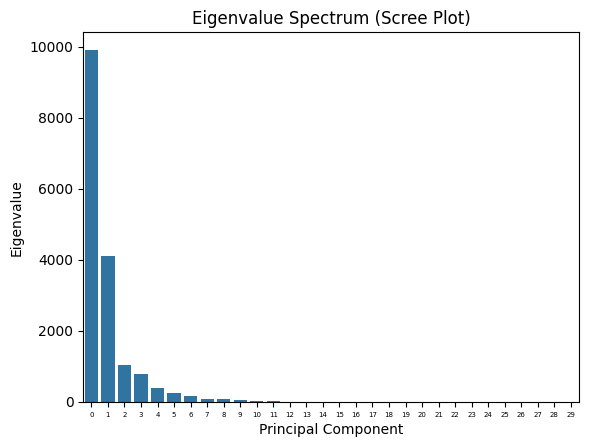

In [14]:
pca = PCA()
pca.fit(XS_train, y_train)

# Get eigenvalues (explained variance)
eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

# print("Eigenvalues and explained variance ratio:")
# for i, (ev, ratio) in enumerate(zip(eigenvalues, explained_ratio)):
#     print(f"  PC{i+1}: eigenvalue = {ev:.4f}, explains {ratio*100:.1f}% of variance")
    
# print(f"\nTotal variance explained: {sum(explained_ratio)*100:.1f}%")

# Scree plot
sns.barplot(x=range(len(eigenvalues)), y=eigenvalues)
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalue Spectrum (Scree Plot)')
plt.xticks(fontsize=5)
plt.show()

In [15]:
pca = PCA(n_components=0.97)
X_train_pca = pca.fit_transform(XS_train, y_train)
X_test_pca = pca.transform(XS_test)

In [16]:
# testing multinomial log regression
MN_LogReg = MN_Logistic_Regression_model(num_classes=5,
                                         x_train=X_train_pca,
                                         y_train=y_train,
                                         x_test=X_test_pca,
                                         y_test=y_test)

/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


training accuracy: 45.49%
testing accuracy: 46.46%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.71', 1: '1.69', 2: '1.70', 3: '1.71', 4: '1.71'}


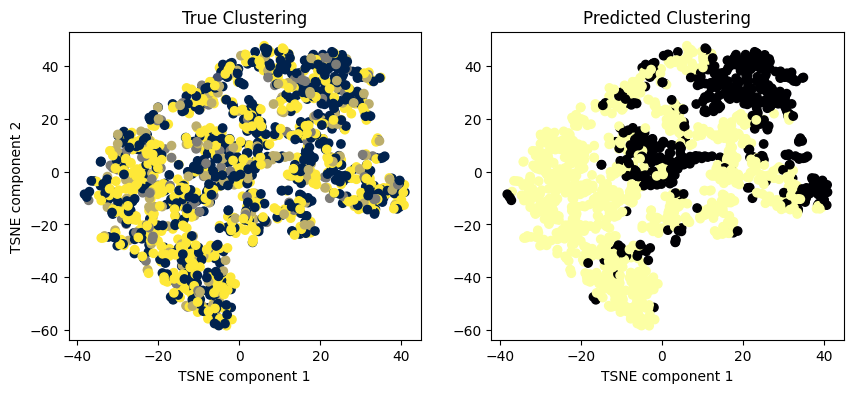

In [17]:
print(MN_LogReg.get_accuracies())
print(MN_LogReg.get_entropy())
MN_LogReg.visualize_clustering()

In [18]:
GMM = Gaussian_Mixture_model(num_components=5,
                             rand_state=0,
                             x_data=X_test_pca,
                             y_data=y_test,
                             target='sfdm2')

{'MAX ENTROPY': 2.321928094887362, 0: '1.69', 1: '1.70', 2: '1.70', 3: '1.41', 4: '1.70'}


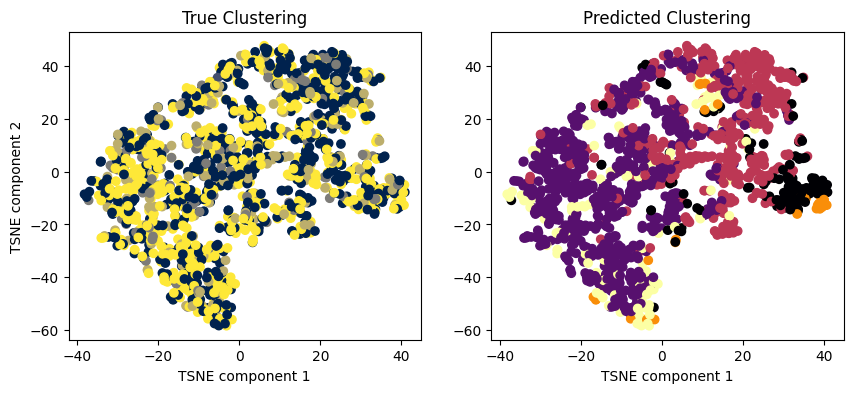

In [19]:
print(GMM.get_entropy())
GMM.visualize_clustering()

In [20]:
NB = Naive_Bayes_model(num_classes=5,
                        x_train=X_train_pca,
                        y_train=y_train,
                        x_test=X_test_pca,
                        y_test=y_test)

/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


training accuracy: 45.64%
testing accuracy: 44.91%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.71', 1: '1.54', 2: '1.71', 3: '1.72', 4: '1.71'}


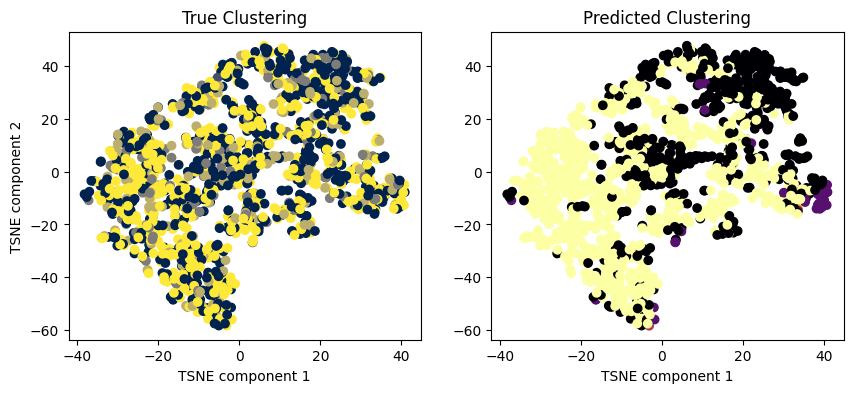

In [21]:
print(NB.get_accuracies())
print(NB.get_entropy())
NB.visualize_clustering()

---------------------------- MN LOGISTIC REGRESSION ----------------------------
training accuracy: 56.41%
testing accuracy: 57.69%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.64', 1: '1.69', 2: '1.70', 3: '1.72', 4: '1.68'}


/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---------------------------- GAUSSIAN MM ----------------------------
{'MAX ENTROPY': 2.321928094887362, 0: '1.39', 1: '1.35', 2: '1.83', 3: '1.72', 4: 'nan'}


/Users/karaha/Documents/4 - MSSE/chem-277a/final-project/277A_Final_Project/models.py:43: RuntimeWarning: divide by zero encountered in log2
  cluster_entropy = float(-np.sum(cluster_probabilities * np.log2(cluster_probabilities)))
/Users/karaha/Documents/4 - MSSE/chem-277a/final-project/277A_Final_Project/models.py:43: RuntimeWarning: invalid value encountered in multiply
  cluster_entropy = float(-np.sum(cluster_probabilities * np.log2(cluster_probabilities)))


---------------------------- NAIVE BAYES ----------------------------
training accuracy: 21.87%
testing accuracy: 22.39%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.19', 1: '1.45', 2: '1.73', 3: '1.67', 4: '1.57'}


/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


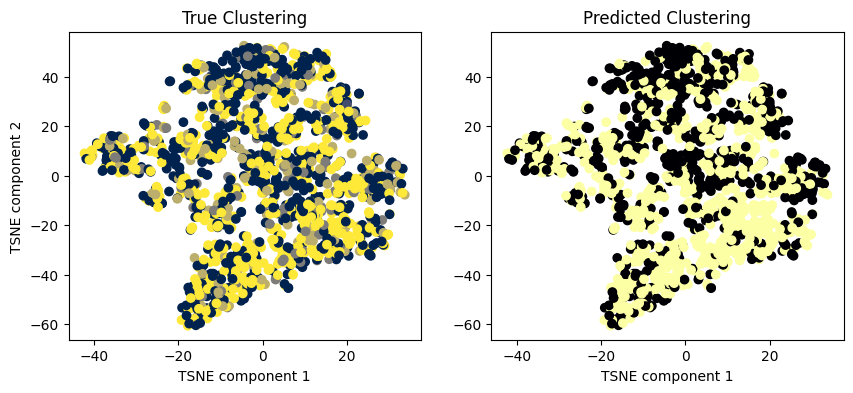

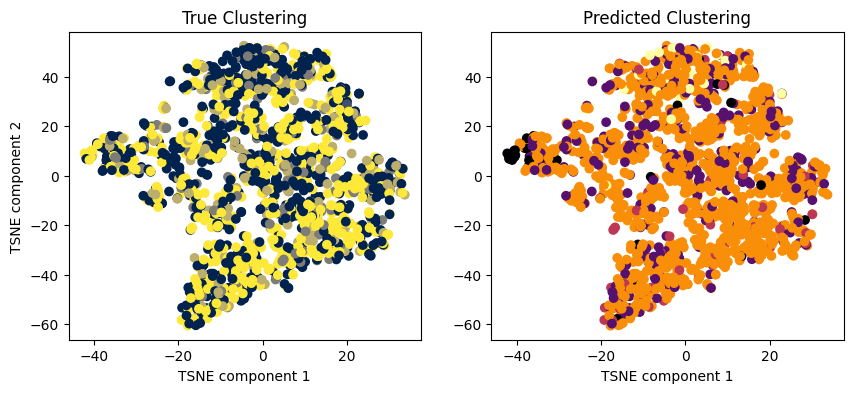

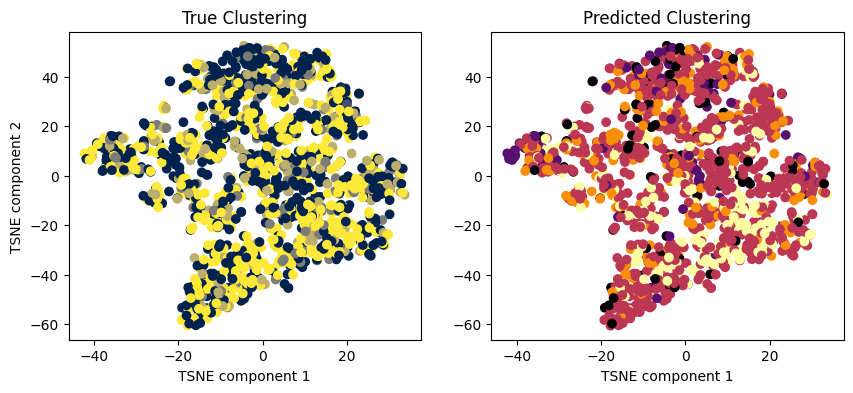

In [22]:
# WITHOUT PCA

print(f'---------------------------- MN LOGISTIC REGRESSION ----------------------------')
MN_LogReg = MN_Logistic_Regression_model(num_classes=5,
                                         x_train=XS_train,
                                         y_train=y_train,
                                         x_test=XS_test,
                                         y_test=y_test)

print(MN_LogReg.get_accuracies())
print(MN_LogReg.get_entropy())
MN_LogReg.visualize_clustering()


print(f'---------------------------- GAUSSIAN MM ----------------------------')
GMM = Gaussian_Mixture_model(num_components=5,
                             rand_state=0,
                             x_data=XS_test,
                             y_data=y_test,
                             target='sfdm2')

print(GMM.get_entropy())
GMM.visualize_clustering()

print(f'---------------------------- NAIVE BAYES ----------------------------')
NB = Naive_Bayes_model(num_classes=5,
                        x_train=XS_train,
                        y_train=y_train,
                        x_test=XS_test,
                        y_test=y_test)

print(NB.get_accuracies())
print(NB.get_entropy())
NB.visualize_clustering()

/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


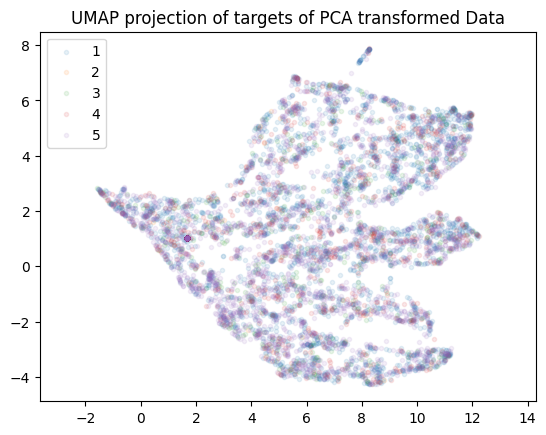

In [26]:
newXY = umap.UMAP().fit_transform(X_train_pca)

le = LabelEncoder()
y_encoded = le.fit_transform(y_train)
y_train = pd.DataFrame(y_encoded, columns=['sfdm2'])

y_test_encoded = le.transform(y_test)
y_test = pd.DataFrame(y_test_encoded, columns=['sfdm2'])

for i in range(np.max(y_train) + 1): 
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.', 
                alpha = 0.1, label = str(i + 1))
    
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets of PCA transformed Data')
plt.legend()
plt.show()

/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


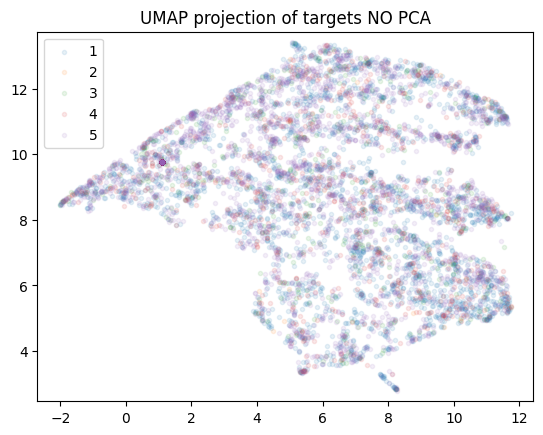

In [27]:
newXY = umap.UMAP().fit_transform(XS_train)

le = LabelEncoder()
y_encoded = le.fit_transform(y_train)
y_train = pd.DataFrame(y_encoded, columns=['sfdm2'])

y_test_encoded = le.transform(y_test)
y_test = pd.DataFrame(y_test_encoded, columns=['sfdm2'])

for i in range(np.max(y_train) + 1): 
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.', 
                alpha = 0.1, label = str(i + 1))
    
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets NO PCA')
plt.legend()
plt.show()